In [2]:
from typing import Annotated, TypedDict
from langgraph.graph import START, StateGraph, END
from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import AIMessage, AnyMessage, BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [18]:
llm = ChatOpenRouter(
    model="inclusionai/ling-3.0-flash-vl",
    temperature=0
)

In [19]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [20]:
def chat_node(state: ChatState):
    decision = interrupt(
        {
            "type": "approval",
            "reason": "Model is about to answer a user question.",
            "question": state["messages"][-1].content,
            "instruction": "Approve this question? yes/no"
        }
    )

    if decision["approved"] == 'no':
        return {
            "messages": [AIMessage(content="Not approved.")]
        }
    else:
        response = llm.invoke(state["messages"])
        return {
            "messages": [response]
        }

In [21]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

checkpointer = InMemorySaver()

app = graph.compile(checkpointer=checkpointer)

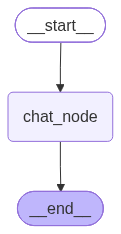

In [22]:
app

In [23]:
config = {
    "configurable": {
        "thread_id": "1234"
    }
}

initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms")
    ]
}

result = app.invoke(initial_input, config=config)

In [24]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms', additional_kwargs={}, response_metadata={}, id='57c0fbc7-1c0e-4ac2-8316-5d81ae1e1c72')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms', 'instruction': 'Approve this question? yes/no'}, id='bc36937c550430c086e4285dadda33b9')]}

In [25]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms',
 'instruction': 'Approve this question? yes/no'}

In [26]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n)")

In [27]:
final_result = app.invoke(
    Command(resume={
        'approved': user_input
    }),
    config=config
)

In [28]:
print(final_result)

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms', additional_kwargs={}, response_metadata={}, id='57c0fbc7-1c0e-4ac2-8316-5d81ae1e1c72'), AIMessage(content='## Gradient Descent — In Simple Terms\n\nImagine you\'re **blindfolded on a hilly landscape**, and your goal is to find the **lowest point** (the valley).\n\nHere\'s what you\'d do:\n\n1. **Feel the slope** beneath your feet — which direction is downhill?\n2. **Take a small step** in that downhill direction.\n3. **Repeat** — feel the slope again, take another small step, and keep going until you\'re as flat as you can get.\n\nThat\'s gradient descent!\n\n### How it applies to machine learning:\n\n- The "hilly landscape" represents your **error** (how wrong your model\'s predictions are).\n- The "lowest point" is the set of **best parameters** (the ones that make your model most accurate).\n- The **gradient** is the math way of figuring out which direction reduces your error the most.\n- The **learn

In [29]:
final_result["messages"][-1].content

'## Gradient Descent — In Simple Terms\n\nImagine you\'re **blindfolded on a hilly landscape**, and your goal is to find the **lowest point** (the valley).\n\nHere\'s what you\'d do:\n\n1. **Feel the slope** beneath your feet — which direction is downhill?\n2. **Take a small step** in that downhill direction.\n3. **Repeat** — feel the slope again, take another small step, and keep going until you\'re as flat as you can get.\n\nThat\'s gradient descent!\n\n### How it applies to machine learning:\n\n- The "hilly landscape" represents your **error** (how wrong your model\'s predictions are).\n- The "lowest point" is the set of **best parameters** (the ones that make your model most accurate).\n- The **gradient** is the math way of figuring out which direction reduces your error the most.\n- The **learning rate** is how big your steps are — too big and you might overshoot, too small and it takes forever.\n\n### In one sentence:\n> **Gradient descent is a method of finding the best solution